# 🔀 Notebook 10 — Multimodal Fusion (Attention-Weighted)
Person 3

In [1]:
!pip install torch tqdm scikit-learn -q

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, json, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# ── Corrected path (shortcut is in MyDrive root, not Colab Notebooks/) ─
BASE_DIR  = "/content/drive/MyDrive/deepfake-project"

# Sanity check
assert os.path.exists(BASE_DIR), (
    f"❌ Not found: {BASE_DIR}\n"
    f"MyDrive contains: {os.listdir('/content/drive/MyDrive')}"
)
print("✅ BASE_DIR found:", BASE_DIR)

MODEL_DIR = os.path.join(BASE_DIR, "models")
EXPL_DIR  = os.path.join(BASE_DIR, "outputs/explanations")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EXPL_DIR, exist_ok=True)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256; EPOCHS = 30; LR = 1e-3; SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"✅ Device: {DEVICE}")

Mounted at /content/drive
✅ BASE_DIR found: /content/drive/MyDrive/deepfake-project
✅ Device: cuda


In [3]:
# ✅ Fusion Network with Attention
class FusionNet(nn.Module):
    MODALITIES = ["Visual","Temporal","Audio","Lip-Sync","Frequency"]
    def __init__(self, n_modalities=5):
        super().__init__()
        self.attention = nn.Sequential(nn.Linear(n_modalities,n_modalities), nn.Softmax(dim=1))
        self.fc = nn.Sequential(
            nn.Linear(n_modalities*2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1),
        )
    def forward(self, x):
        w = self.attention(x); c = torch.cat([x, w*x], dim=1)
        return self.fc(c).squeeze(1)
    def explain(self, x):
        with torch.no_grad():
            w = self.attention(x.unsqueeze(0)).squeeze(0)
        return {m: float(w[i]) for i,m in enumerate(self.MODALITIES)}

model     = FusionNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print("✅ FusionNet ready.")

✅ FusionNet ready.


In [4]:
# ✅ Generate synthetic score vectors for fusion training
# (Replace with real inference scores from your trained models)
def make_synthetic_scores(n=2000):
    np.random.seed(SEED)
    real_scores = np.random.beta(2,5,(n//2,5)).astype(np.float32)
    fake_scores = np.random.beta(5,2,(n//2,5)).astype(np.float32)
    X = np.vstack([real_scores, fake_scores])
    y = np.array([0]*(n//2)+[1]*(n//2), dtype=np.float32)
    idx = np.random.permutation(n); return X[idx], y[idx]

X_all, y_all = make_synthetic_scores(2000)
n_val = int(len(X_all)*0.15)
X_tr,y_tr = X_all[n_val:],y_all[n_val:]
X_va,y_va = X_all[:n_val],y_all[:n_val]

class ScoreDataset(Dataset):
    def __init__(self, X, y): self.X=torch.tensor(X); self.y=torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

tr_dl = DataLoader(ScoreDataset(X_tr,y_tr),batch_size=BATCH_SIZE,shuffle=True)
va_dl = DataLoader(ScoreDataset(X_va,y_va),batch_size=BATCH_SIZE)
print(f"✅ Train: {len(X_tr)}, Val: {len(X_va)}")

✅ Train: 1700, Val: 300


In [5]:
# ✅ Training
best_auc = 0.0
for epoch in range(1, EPOCHS+1):
    model.train(); tr_loss = 0
    for x, y in tr_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(); loss = criterion(model(x),y)
        loss.backward(); optimizer.step(); tr_loss += loss.item()
    model.eval(); probs, lbls_all = [], []
    with torch.no_grad():
        for x, y in va_dl:
            p = torch.sigmoid(model(x.to(DEVICE))).cpu().numpy()
            probs.extend(p); lbls_all.extend(y.numpy())
    auc = roc_auc_score(lbls_all, probs)
    acc = accuracy_score(lbls_all, [p>0.5 for p in probs])
    if epoch % 5 == 0:
        print(f"  Epoch {epoch}: loss={tr_loss/len(tr_dl):.4f}  val_acc={acc:.4f}  val_auc={auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR,"fusion_model.pth"))
print(f"\n✅ Done. Best AUC: {best_auc:.4f}")

  Epoch 5: loss=0.5809  val_acc=0.8267  val_auc=0.9999
  Epoch 10: loss=0.3148  val_acc=0.9867  val_auc=0.9999
  Epoch 15: loss=0.1202  val_acc=0.9900  val_auc=0.9999
  Epoch 20: loss=0.0583  val_acc=0.9900  val_auc=0.9999
  Epoch 25: loss=0.0331  val_acc=0.9900  val_auc=0.9999
  Epoch 30: loss=0.0234  val_acc=0.9933  val_auc=1.0000

✅ Done. Best AUC: 1.0000


{
  "final_probability": 0.9978,
  "verdict": "FAKE",
  "confidence_pct": 99.8,
  "modality_scores": {
    "Visual": 0.92,
    "Temporal": 0.78,
    "Audio": 0.85,
    "Lip-Sync": 0.15,
    "Frequency": 0.88
  },
  "attention_weights": {
    "Visual": 0.3807,
    "Temporal": 0.0624,
    "Audio": 0.4119,
    "Lip-Sync": 0.1136,
    "Frequency": 0.0315
  }
}


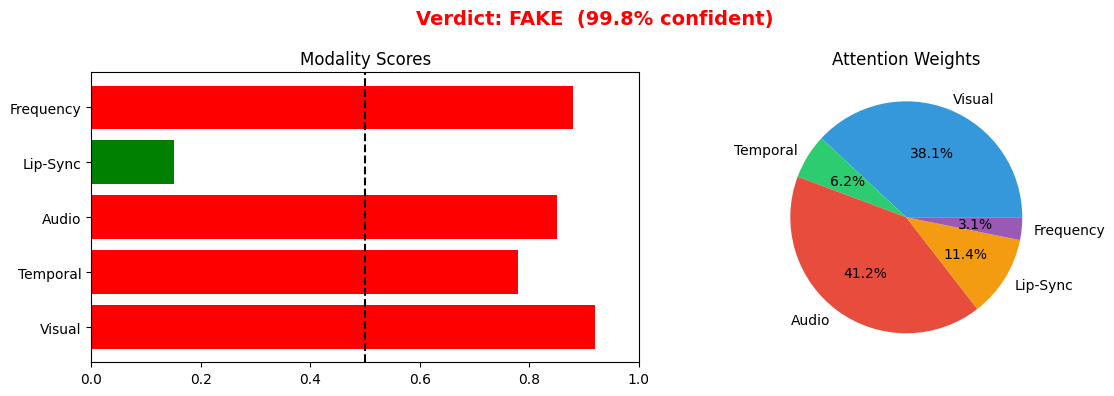

In [6]:
# ✅ Prediction + Attention Visualization
def predict_video(p_visual, p_temporal, p_audio, sync_score, p_freq):
    net = FusionNet().to(DEVICE)
    net.load_state_dict(torch.load(os.path.join(MODEL_DIR,"fusion_model.pth"), map_location=DEVICE))
    net.eval()
    scores = torch.tensor([p_visual,p_temporal,p_audio,sync_score,p_freq], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        final_prob = torch.sigmoid(net(scores.unsqueeze(0))).item()
    attn    = net.explain(scores)
    verdict = "FAKE" if final_prob > 0.5 else "REAL"
    conf    = final_prob if verdict=="FAKE" else 1-final_prob
    return {"final_probability":round(final_prob,4),"verdict":verdict,
            "confidence_pct":round(conf*100,1),
            "modality_scores":{"Visual":round(p_visual,4),"Temporal":round(p_temporal,4),
                                "Audio":round(p_audio,4),"Lip-Sync":round(sync_score,4),
                                "Frequency":round(p_freq,4)},
            "attention_weights":{k:round(v,4) for k,v in attn.items()}}

# Demo
result = predict_video(0.92, 0.78, 0.85, 0.15, 0.88)
print(json.dumps(result, indent=2))

# Plot
MODS = ["Visual","Temporal","Audio","Lip-Sync","Frequency"]
fig, axes = plt.subplots(1,2,figsize=(12,4))
mscores = [result["modality_scores"][m] for m in MODS]
axes[0].barh(MODS, mscores, color=["red" if s>0.5 else "green" for s in mscores])
axes[0].axvline(0.5,color="black",linestyle="--"); axes[0].set_xlim(0,1)
axes[0].set_title("Modality Scores")
aw = [result["attention_weights"][m] for m in MODS]
axes[1].pie(aw, labels=MODS, autopct="%1.1f%%",
            colors=["#3498db","#2ecc71","#e74c3c","#f39c12","#9b59b6"])
axes[1].set_title("Attention Weights")
fig.suptitle(f"Verdict: {result['verdict']}  ({result['confidence_pct']}% confident)",
             fontsize=14, fontweight="bold", color="red" if result['verdict']=="FAKE" else "green")
plt.tight_layout(); plt.show()